# 03 · Каталог раскидок

Логика — `src/lineups.py`; артефакты — `data/lineups.parquet`, `data/throw_lineup.parquet`.

**Раскидка** = повторяемый бросок «откуда → куда». Для каждой пары тип × сторона:
1. HDBSCAN на 60k бросков по (throw_x, throw_y, land_x, land_y);
2. присвоение ближайшему кластеру в радиусе 50 ед., иначе «ситуативный».

Прыжок, присед и прицел в кластеризацию не входят — это техника раскидки.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lineups as L
from mapviz import draw_lineups

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3})

throws = pd.read_parquet("../data/throws.parquet")
lineups = pd.read_parquet("../data/lineups.parquet")
lineup_throws = throws.merge(pd.read_parquet("../data/throw_lineup.parquet"), on="grenade_id")

print(f"раскидок: {len(lineups):,} | бросков в раскидках: {len(lineup_throws):,} из {len(throws):,} ({len(lineup_throws)/len(throws):.0%})")
print(
    f"параметры: SAMPLE={L.SAMPLE}, MIN_CLUSTER_SIZE={L.MIN_CLUSTER_SIZE}, "
    f"MIN_SAMPLES={L.MIN_SAMPLES}, METHOD={L.METHOD}, ASSIGN_RADIUS={L.ASSIGN_RADIUS}"
)

раскидок: 1,362 | бросков в раскидках: 1,214,143 из 2,385,417 (51%)
параметры: SAMPLE=60000, MIN_CLUSTER_SIZE=30, MIN_SAMPLES=10, METHOD=leaf, ASSIGN_RADIUS=50


## 1. Выбор метода: `eom` vs `leaf`

In [2]:
def cluster_quality(group, labels):
    clustered = group.assign(cluster=labels)[labels >= 0]
    medians = clustered.groupby("cluster")[L.FEATURES].transform("median")
    spread = pd.DataFrame(
        {
            "throw": np.hypot(clustered.throw_x - medians.throw_x, clustered.throw_y - medians.throw_y),
            "land": np.hypot(clustered.land_x - medians.land_x, clustered.land_y - medians.land_y),
            "cluster": clustered.cluster,
        }
    ).groupby("cluster").median()
    return {
        "раскидок": labels.max() + 1,
        "покрытие %": np.mean(labels >= 0) * 100,
        "крупнейшая, % группы": clustered.cluster.value_counts().iloc[0] / len(group) * 100,
        "разброс броска p90": spread["throw"].quantile(0.9),
        "разброс падения p90": spread.land.quantile(0.9),
    }


method_rows = {}
for grenade_type, side in [("smoke", "CT"), ("flash", "T")]:
    subset = throws[(throws.type == grenade_type) & (throws.side == side)]
    for method in ["eom", "leaf"]:
        labels = L.cluster_group(subset, method=method)
        method_rows[(f"{grenade_type}-{side}", method)] = cluster_quality(subset, labels)
pd.DataFrame(method_rows).T.round(1)

раскидок  покрытие %  крупнейшая, % группы  разброс броска p90  разброс падения p90
smoke-CT eom       66.0        75.8                  27.7                99.7                112.9
         leaf     118.0        59.3                   7.9                79.9                 81.2
flash-T  eom      105.0        61.5                   7.9               116.8                140.9
         leaf     152.0        43.9                   3.8               100.2                118.5

Выбран **`leaf`**: раскидки компактнее (разброс ~80–100 единиц против 100–140), нет «мега-кластеров».
Цена — ниже покрытие, но это честнее: ситуативные броски не притягиваются к раскидкам насильно.

## 2. Сколько бросков — это раскидки

In [3]:
coverage_pct = (
    lineup_throws.groupby(["type", "side"]).size()
    / throws.groupby(["type", "side"], observed=True).size()
).unstack().mul(100).round(0)

lineup_stats = lineups.groupby(["type", "side"]).agg(
    раскидок=("n", "size"),
    медиана_бросков=("n", "median"),
    разброс_броска=("throw_spread", "median"),
    разброс_падения=("land_spread", "median"),
)
lineup_stats["покрытие %"] = [coverage_pct.loc[a, b] for a, b in lineup_stats.index]
lineup_stats.round(1)

раскидок  медиана_бросков  разброс_броска  разброс_падения  покрытие %
type  side                                                                        
fire  CT         171            488.0            38.5             53.6        57.0
      T          203            325.0            41.1             52.7        53.0
flash CT         173            417.0            41.4             54.1        41.0
      T          152            583.0            47.5             54.5        44.0
he    CT         177            568.0            40.9             51.3        53.0
      T          186            421.0            44.4             52.7        51.0
smoke CT         118           1039.5            37.3             37.2        59.0
      T          182            501.5            43.5             46.4        49.0

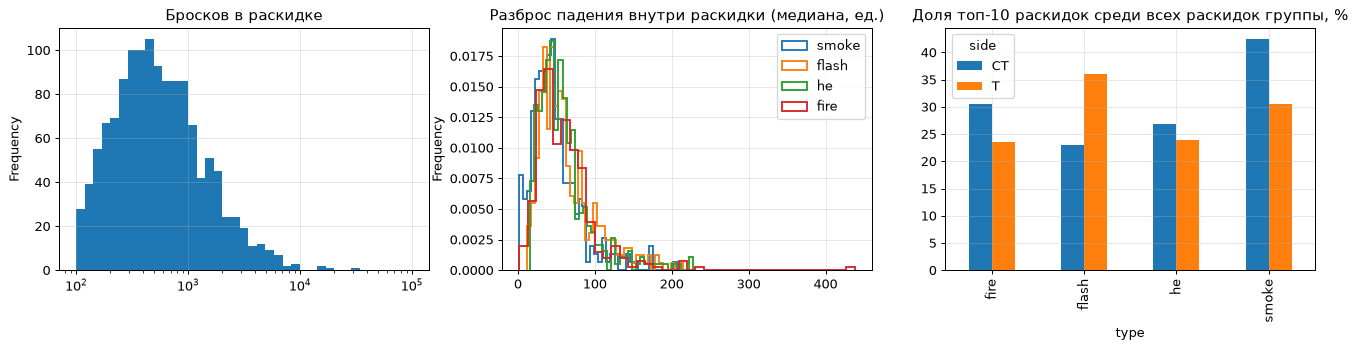

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(18, 3.5))
lineups.n.plot.hist(bins=np.logspace(2, 5, 40), ax=axs[0], logx=True, title="Бросков в раскидке")
for grenade_type in ["smoke", "flash", "he", "fire"]:
    lineups[lineups.type == grenade_type].land_spread.plot.hist(
        bins=40, ax=axs[1], histtype="step", lw=1.5, label=grenade_type, density=True
    )
axs[1].set_title("Разброс падения внутри раскидки (медиана, ед.)")
axs[1].legend()
top_share = lineups.sort_values("n", ascending=False).groupby(["type", "side"]).n.apply(
    lambda counts: counts.head(10).sum() / counts.sum() * 100
)
top_share.unstack().plot.bar(ax=axs[2], title="Доля топ-10 раскидок среди всех раскидок группы, %")

- Смоки — самые «заученные»: медианный разброс падения 37–46 ед. против ~53 у остальных; у смоков CT топ-10 раскидок — 42% всех их раскидочных бросков.
- Флешки T сильнее сконцентрированы в топ-10 (36%), чем флешки CT (23%): у T есть «стандартные» заходы.
- Для справки: 1 игровая единица ≈ 2.5 см, игрок ≈ 32 ед. в ширину, облако смока ≈ 288 ед. в диаметре.

## 3. Топ раскидки на карте

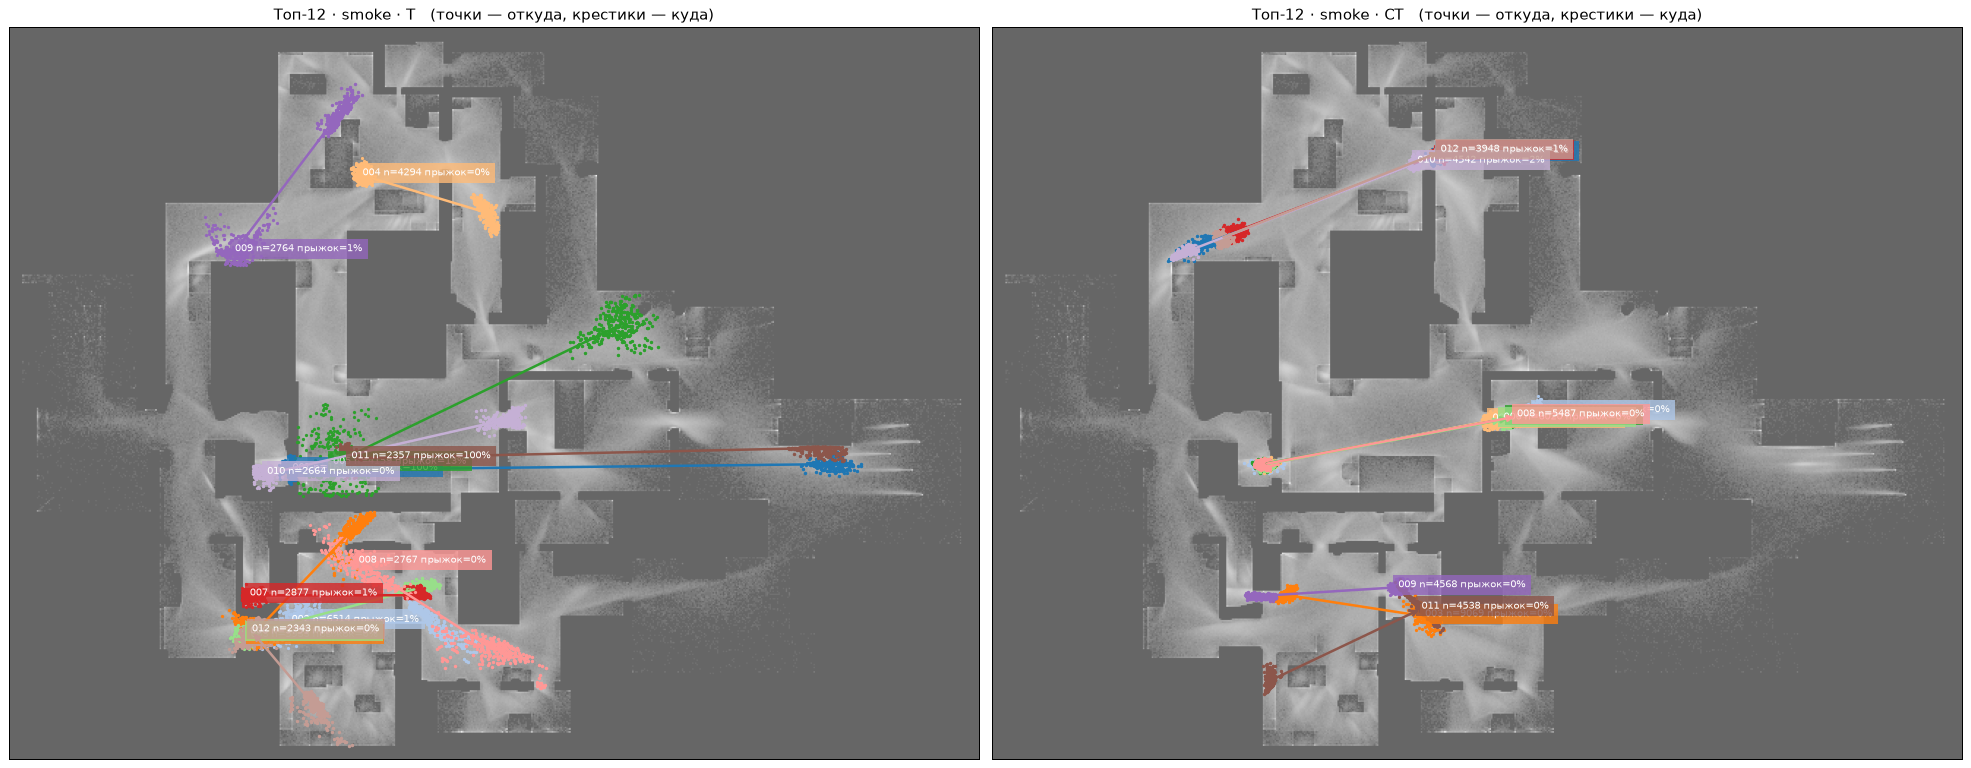

In [5]:
def show_top_lineups(grenade_type, k=12):
    fig, axs = plt.subplots(1, 2, figsize=(22, 9))
    for ax, side in zip(axs, ["T", "CT"]):
        top = lineups[(lineups.type == grenade_type) & (lineups.side == side)].head(k)
        draw_lineups(ax, top, lineup_throws)
        ax.set_title(f"Топ-{k} · {grenade_type} · {side}   (точки — откуда, крестики — куда)")
    plt.tight_layout()


show_top_lineups("smoke")

`smoke-T-001` — классический смок с T-спавна в прыжке (100% бросков — jump-throw, 16k раз, 5k разных игроков).
У CT раскидки короткие и компактные: смоки из-за точки на проходы.

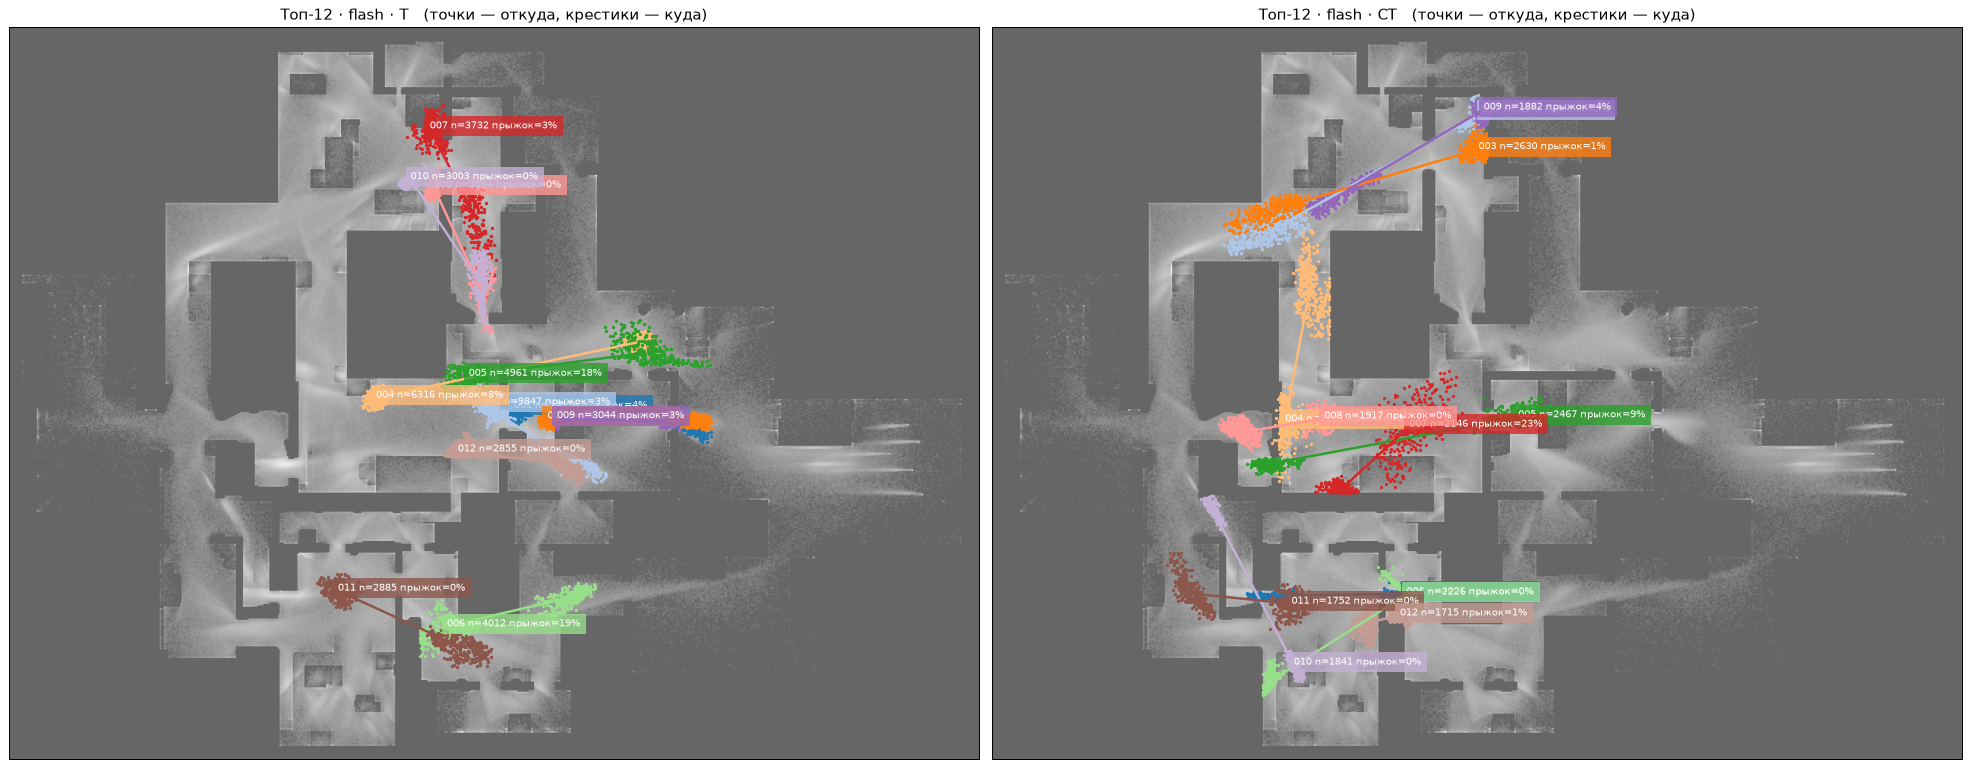

In [6]:
show_top_lineups("flash")

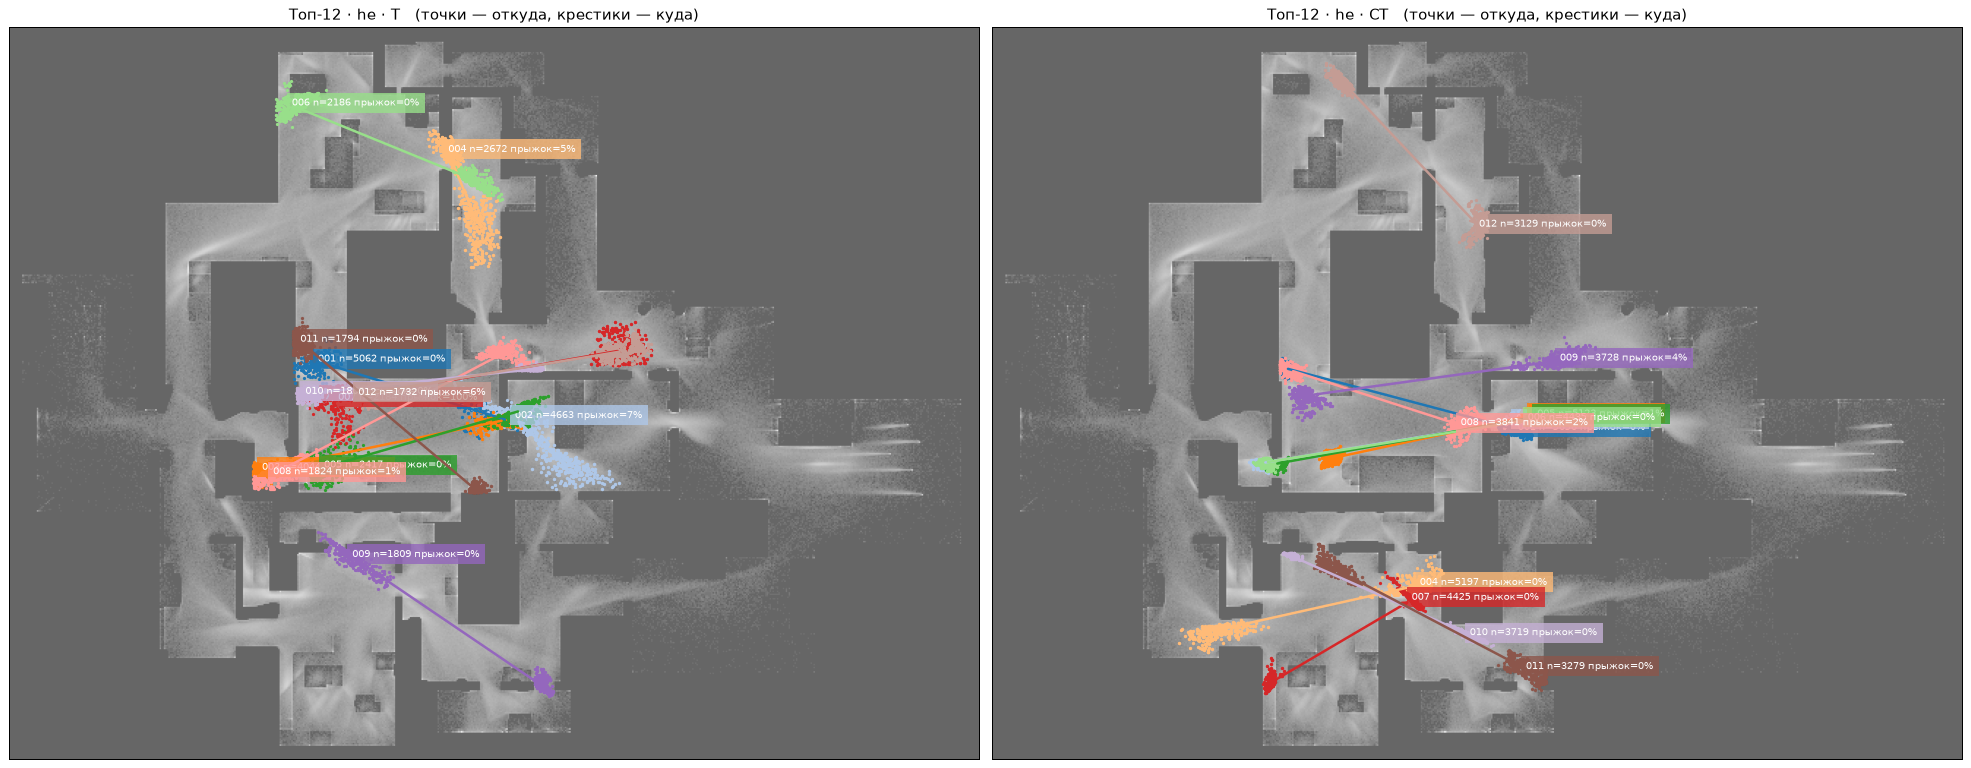

In [7]:
show_top_lineups("he")

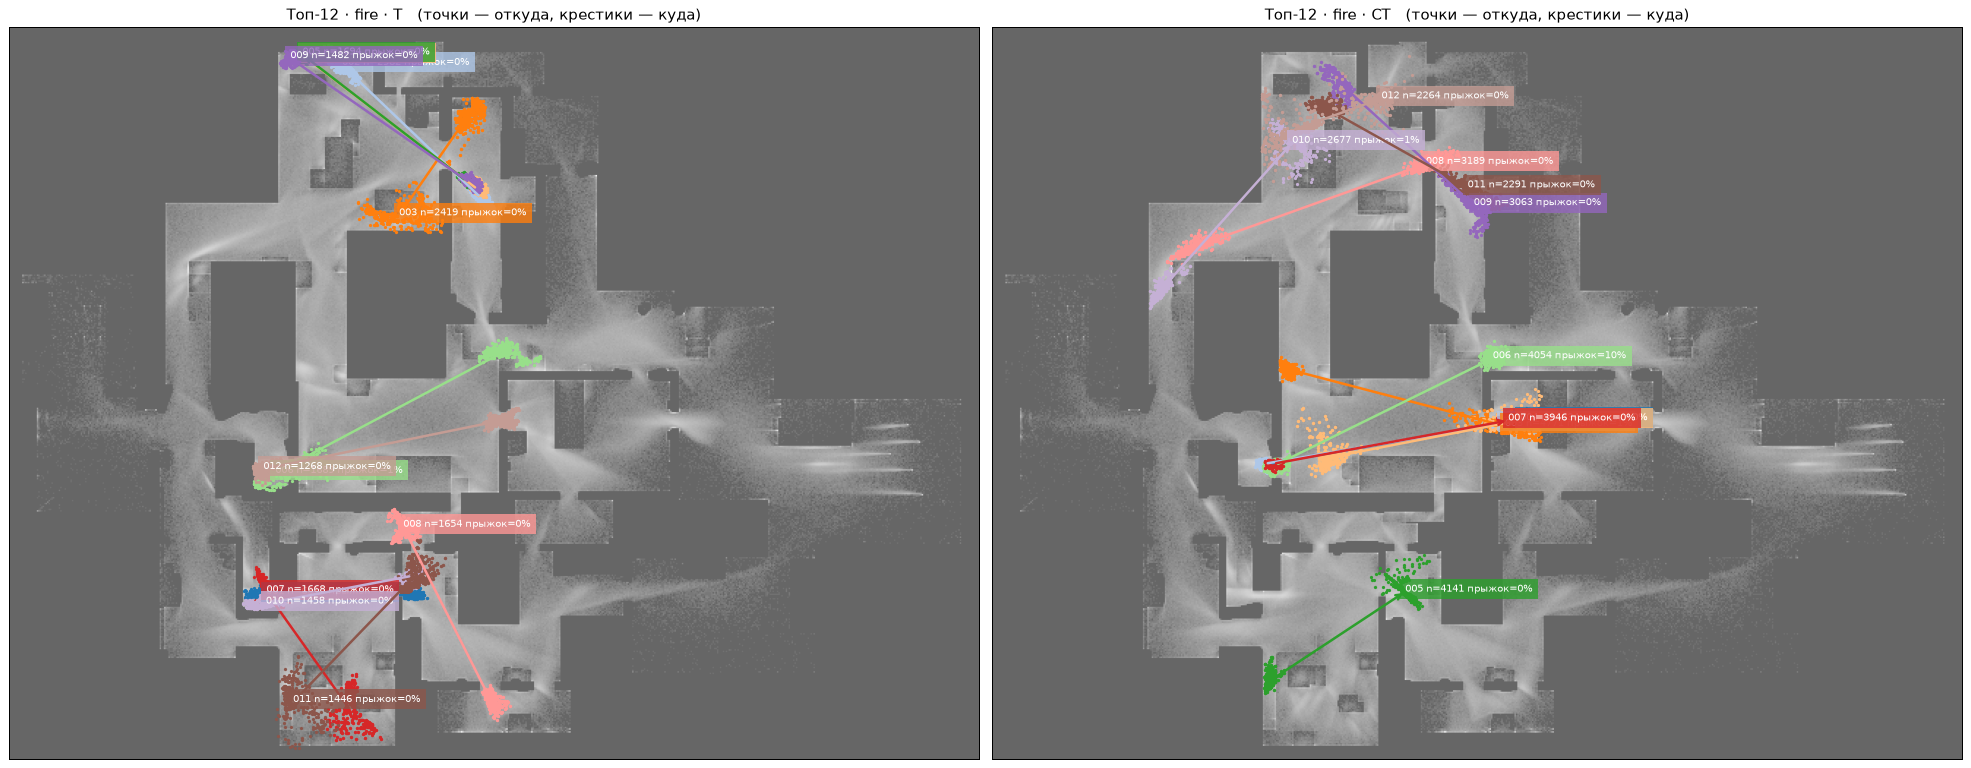

In [8]:
show_top_lineups("fire")

## 4. Техника раскидки

раскидок со смешанной техникой (20–80% в прыжке): 3.5%


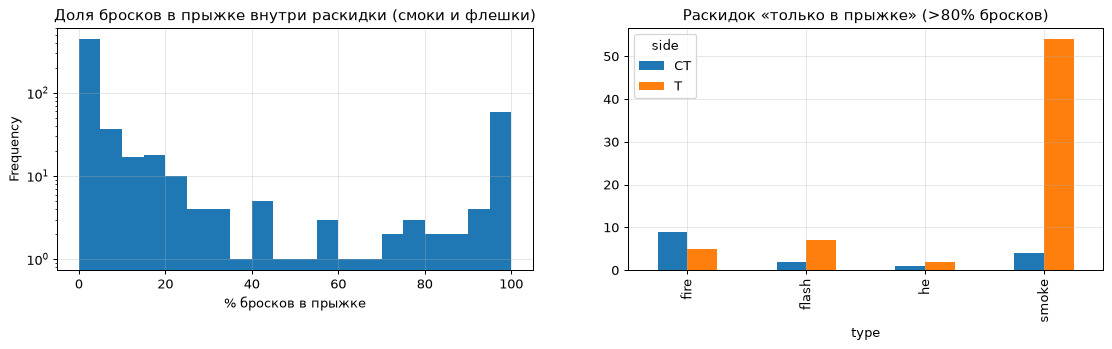

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 3.5))
lineups[lineups.type.isin(["smoke", "flash"])].airborne.mul(100).plot.hist(
    bins=20, ax=axs[0], logy=True, title="Доля бросков в прыжке внутри раскидки (смоки и флешки)"
)
axs[0].set_xlabel("% бросков в прыжке")
lineups[lineups.airborne > 0.8].groupby(["type", "side"]).size().unstack().plot.bar(
    ax=axs[1], title="Раскидок «только в прыжке» (>80% бросков)"
)
mixed_share = ((lineups.airborne > 0.2) & (lineups.airborne < 0.8)).mean()
print(f"раскидок со смешанной техникой (20–80% в прыжке): {mixed_share:.1%}")

Распределение двугорбое: только 3.5% раскидок имеют смешанную технику (20–80% в прыжке).
Раскидки «только в прыжке» — это почти исключительно **смоки T** (54 шт.): дальние смоки со спавна и выходов.
Значит, **«кинул без прыжка раскидку, которую все кидают в прыжке»** — осмысленный сигнал ошибки для персонального совета.

## 5. Прицел внутри раскидки

In [10]:
throws_with_aim = lineup_throws.join(
    lineups[["view_yaw", "view_pitch"]].add_suffix("_catalog"), on="lineup_id"
)
throws_with_aim["yaw_dev"] = ((throws_with_aim.view_yaw - throws_with_aim.view_yaw_catalog + 180) % 360 - 180).abs()
throws_with_aim["pitch_dev"] = (throws_with_aim.view_pitch - throws_with_aim.view_pitch_catalog).abs()

aim_by_lineup = throws_with_aim.groupby("lineup_id")[["yaw_dev", "pitch_dev"]].median().join(lineups[["type"]])
aim_by_lineup.groupby("type")[["yaw_dev", "pitch_dev"]].describe(percentiles=[0.5, 0.9]).loc[:, (slice(None), ["50%", "90%"])].round(1)

yaw_dev       pitch_dev      
          50%   90%       50%   90%
type                               
fire      1.9   6.5       1.6   3.3
flash     3.0  12.3       2.6  13.9
he        2.2   7.1       1.8   4.1
smoke     1.5   7.8       2.1   5.4

Медианное отклонение прицела — 1.5–3°; у флешек хвост шире (p90 ≈ 12–14°).
→ Привязка по намерению (позиция + прицел) и оценка промаха относительно нормы.

## 6. Самые массовые раскидки

In [11]:
display_cols = ["type", "side", "n", "players", "group_share", "throw_spread", "land_spread", "airborne", "crouch"]
lineups.sort_values("n", ascending=False)[display_cols].head(20).style.format(
    {"group_share": "{:.1%}", "airborne": "{:.0%}", "crouch": "{:.0%}", "throw_spread": "{:.0f}", "land_spread": "{:.0f}"}
)

,type,side,n,players,group_share,throw_spread,land_spread,airborne,crouch
lineup_id,,,,,,,,,
smoke-CT-001,smoke,CT,30395,12575,7.9%,55,33,1%,0%
smoke-CT-002,smoke,CT,17242,10058,4.5%,32,26,0%,0%
smoke-T-001,smoke,T,16108,5387,4.7%,50,24,100%,0%
flash-T-001,flash,T,14356,7625,3.8%,64,36,4%,0%
flash-T-002,flash,T,9847,6580,2.6%,68,85,3%,1%
fire-CT-001,fire,CT,9079,5442,3.5%,26,32,0%,0%
smoke-CT-003,smoke,CT,9069,2734,2.4%,25,51,0%,0%
flash-T-003,flash,T,7824,4986,2.1%,43,31,1%,0%
smoke-CT-004,smoke,CT,7204,4400,1.9%,26,26,0%,0%


## Выводы

1. **1 362 раскидки**, покрывают ~51% всех бросков (смоки CT — 59%, флешки — 41–44%).
2. Раскидки **компактные**: медианный разброс падения ~37–55 ед. — это ~1–2 ширины игрока, при облаке смока ≈ 288 ед.
3. **Техника однозначна** почти в каждой раскидке → несоответствие техники — сигнал ошибки.
4. **Прицел стабилен** → бросок можно привязать к раскидке по намерению и оценить промах.

→ Дальше (04): нормы результата для каждой раскидки + привязка по намерению.